# 01 · Carbon stocks, seasons and environmental associations

## Context and questions

The supplied introduction and literature review compare carbon storage in **Loktak
and Pumlen lakes**, considering soil, macrophytes and phytoplankton. This notebook
addresses two descriptive questions: how do the measured carbon variables vary by
lake and season, and how do they covary with the environmental measurements?

**Contents:** (1) check data and sampling keys; (2) plot seasonal profiles;
(3) examine paired scatter plots within each lake; (4) compare pooled and within-lake
correlations; (5) state the conclusions and their limits.

Measurements come from `Scatter Plot.xlsx` and `PCA.xlsx`. The chapters provide the
scientific context, not additional measurements. Stock measurements alone cannot
estimate a sequestration rate or establish effects of disturbance.

Run from top to bottom with **Python (ler)**. Keep the three Excel files and
`ecological_data.py` in the parent project folder, above `ipynb_files_2/`.
The kernel may start in either folder. Every plot is saved under
`ipynb_files_2/figures/`
as a vector PDF and a 300-dpi PNG, **160 mm wide**. Labels are 9.5–12 pt at that
printed width. Use the figures at full text width, not as half-width thumbnails.
The source spreadsheets are unchanged; numerical tables are under `ipynb_files_2/tables/`.

## What one observation represents

Each measurement is keyed by **wetland, year, season and site**. Each lake has five
site codes, observed in four seasons and two years. Means below give those five
sites equal weight; they are not area-weighted estimates of whole-lake stocks.
The 40 records per lake must not be treated as 40 independent sites.

Environmental and phytoplankton-carbon units are absent from the measurement
headers. Values are retained without guessing units. Soil stock is labelled in
Mg C ha⁻¹ as stated in its source heading. SOC is a separate variable from stock.

**Source restriction:** the 80 values in the raw TBC-labelled block exactly match
water TDS. They are excluded from biomass analysis. Only the supplied seasonal
TBC means are plotted. Its summary does not specify a unit or define the “±” term;
both remain unconfirmed rather than inheriting metadata from the suspect raw block.

In [1]:
FIGURE_GROUP = "01_carbon"

from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display
# Locate the project root when the kernel starts here or in the parent folder.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "ecological_data.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the lyn project or ipynb_files_2 folder.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ecological_data import (
    ROOT, KEYS, SEASONS, WETLANDS, load_scatter, load_pca,
    decode_pca, load_line_summary, load_heatmaps,
)

NOTEBOOK_DIR = ROOT / "ipynb_files_2"
FIG_DIR = NOTEBOOK_DIR / "figures" / FIGURE_GROUP
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = NOTEBOOK_DIR / "tables"
TABLE_DIR.mkdir(exist_ok=True)
# A4 with 25-mm left/right margins: 160 mm available for a figure.
WIDTH = 160 / 25.4  # inches; figures should be placed at this width in the thesis
FIGURES = []
sns.set_theme(style="ticks", context="notebook", font="DejaVu Sans", rc={
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "legend.title_fontsize": 10,
    "figure.dpi": 130, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42,
})
PALETTE = dict(zip(WETLANDS, sns.color_palette("colorblind", 2)))
MARKERS = dict(zip(SEASONS, ["o", "s", "^", "D"]))
LABELS = {
    "Soil_stock": r"Soil carbon stock (Mg C ha$^{-1}$)",
    "Phyto_carbon": "Phytoplankton carbon\n(unit not supplied)",
    "TBC": "Total biomass carbon\n(unit unconfirmed)",
    "Soil_Temp": "Soil temperature", "Water_Temp": "Water temperature",
    "Soil_pH": "Soil pH", "Water_pH": "Water pH", "BD": "Bulk density",
    "Moisture": "Soil moisture", "SOC": "Soil organic carbon (SOC)",
    "N": "Available nitrogen", "P": "Available phosphorus", "K": "Available potassium",
    "TDS": "Total dissolved solids (TDS)", "EC": "Electrical conductivity (EC)",
    "CO2": r"Free CO$_2$", "Turbidity": "Turbidity", "DO": "Dissolved oxygen (DO)",
    "BOD": "Biochemical oxygen demand", "COD": "Chemical oxygen demand",
    "Alkalinity": "Alkalinity", "Hardness": "Total hardness",
    "Water_K": "Water potassium", "Inorg_P": "Inorganic phosphorus",
}


SEASON_TICKS = ["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"]

def lake_handles(shape_by_lake=False):
    return [Line2D([], [], color=PALETTE[w], marker="s" if shape_by_lake and w == "Pumlen" else "o",
                   linestyle="", label=w, markersize=5) for w in WETLANDS]

def season_handles():
    return [Line2D([], [], color="0.2", marker=MARKERS[s], linestyle="",
                   label=s, markersize=5) for s in SEASONS]

def save_show(fig, name, caption):
    """Export at a fixed physical width; captions also accompany the A4 proof PDF."""
    assert np.isclose(fig.get_figwidth(), WIDTH)
    assert fig.get_figheight() <= 8.4  # leave room for a caption on A4
    # Do not use bbox_inches='tight': it changes the physical page dimensions.
    for extension in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{extension}", facecolor="white")
    FIGURES.append({"file":name, "caption":caption})
    (FIG_DIR / "captions.json").write_text(json.dumps(FIGURES, indent=2))
    plt.show()
    plt.close(fig)

# Use linear axes for this dataset. Optional display-only overrides never change
# the values used for correlations or PCA. Log axes do not resolve exact overlaps.
SCALE_OVERRIDES = {}
def axis_scale(values, variable):
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    choice = SCALE_OVERRIDES.get(variable, "linear")
    assert choice in {"linear", "log"}
    if choice == "log" and np.any(values <= 0):
        raise ValueError(f"Cannot use log scale for nonpositive {variable} values.")
    return choice

def set_numeric_axis(ax, axis, values, variable):
    scale = axis_scale(values, variable)
    getattr(ax, f"set_{axis}scale")(scale)
    getattr(ax, f"set_{axis}label")(LABELS.get(variable, variable) + (" [log scale]" if scale == "log" else ""))

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | seaborn {sns.__version__}")
print(f"Figures: {FIG_DIR}")

Python 3.10.18 | pandas 2.3.0 | seaborn 0.13.2
Figures: /Users/phurailatpamhemantakumar/phd/mypackages/lyn/ipynb_files_2/figures/01_carbon


## 1. Verify matching and inspect the data

In [2]:
scatter, source_blocks = load_scatter()
pca_raw = load_pca()
environment = {name: decode_pca(frame) for name, frame in pca_raw.items()}
reported = load_line_summary()

# Check the candidate code mapping against every overlapping named measurement.
mapping_checks = []
for compartment, frame in environment.items():
    shared = [c for c in frame if c in scatter and c not in KEYS]
    paired = frame.merge(scatter, on=KEYS, suffixes=("_pca", "_scatter"), validate="one_to_one")
    assert len(paired) == len(frame) == len(scatter) == 80
    for variable in shared:
        delta = (paired[f"{variable}_pca"] - paired[f"{variable}_scatter"]).abs()
        mapping_checks.append({"Compartment": compartment, "Variable": variable,
                               "Matched records": len(delta), "Maximum difference": delta.max()})
mapping_checks = pd.DataFrame(mapping_checks)
assert (mapping_checks["Maximum difference"] < 1e-10).all()
display(mapping_checks)
print("Verified: wetland 1 = Loktak, 2 = Pumlen; year 1 = 2022, 2 = 2023.")
print("Season 1–4 = pre-monsoon, monsoon, post-monsoon, winter.")

data = scatter.merge(environment["Soil"][KEYS + ["SOC"]], on=KEYS, validate="one_to_one")
check_tbc = data.merge(environment["Water"][KEYS + ["TDS"]], on=KEYS, validate="one_to_one")
assert np.array_equal(check_tbc.TBC_block_unverified, check_tbc.TDS)
print("Source issue: 80/80 entries in the TBC-labelled block exactly equal TDS.")
display(data.groupby(["Wetland", "Year", "Season"]).size().unstack("Season")[SEASONS])
data.drop(columns="TBC_block_unverified").to_csv(TABLE_DIR / "carbon_and_soil_measurements.csv", index=False)
pd.concat([frame.assign(Variable=name).rename(columns={name:"Value"})
           for name, frame in source_blocks.items()], ignore_index=True).to_csv(
    TABLE_DIR / "scatter_cell_provenance.csv", index=False)

,Compartment,Variable,Matched records,Maximum difference
0,Water,Water_Temp,80,0.0
1,Water,CO2,80,0.0
2,Water,Hardness,80,0.0
3,Soil,Soil_pH,80,0.0
4,Soil,BD,80,0.0
5,Soil,Moisture,80,0.0
6,Soil,N,80,0.0
7,Soil,P,80,0.0
8,Soil,K,80,0.0


Verified: wetland 1 = Loktak, 2 = Pumlen; year 1 = 2022, 2 = 2023.
Season 1–4 = pre-monsoon, monsoon, post-monsoon, winter.
Source issue: 80/80 entries in the TBC-labelled block exactly equal TDS.


Season        Pre-monsoon  Monsoon  Post-monsoon  Winter
Wetland Year                                            
Loktak  2022            5        5             5       5
        2023            5        5             5       5
Pumlen  2022            5        5             5       5
        2023            5        5             5       5

## 2. Check the precomputed seasonal table

For available site-level carbon data, recompute
\[
\bar x=\frac{1}{n}\sum_i x_i,\qquad
s=\sqrt{\frac{\sum_i(x_i-\bar x)^2}{n-1}},\qquad n=5.
\]
The audit retains both versions. In particular, Loktak 2022 monsoon phytoplankton
carbon averages **493.898** in the site data, compared with **489.89** in `Line_Graph!G13`.
Plots below use the site-data mean. The source spreadsheet is unchanged.

In [3]:
seasonal = data.melt(id_vars=KEYS, value_vars=["Soil_stock", "Phyto_carbon"],
                     var_name="Variable", value_name="Value")
seasonal = seasonal.groupby(["Variable", "Wetland", "Year", "Season"], as_index=False).agg(
    Mean=("Value", "mean"), SD=("Value", "std"), N=("Value", "size"))
assert (seasonal.N == 5).all()
audit = seasonal.merge(reported, on=["Variable", "Wetland", "Year", "Season"],
                       suffixes=("_raw", "_reported"), validate="one_to_one")
audit["Mean_difference"] = audit.Mean_raw - audit.Mean_reported
audit["SD_minus_reported_spread"] = audit.SD - audit.Reported_spread
display(audit[["Variable", "Wetland", "Year", "Season", "Mean_raw", "Mean_reported",
               "Mean_difference", "SD", "Reported_spread"]].round(4))
audit.to_csv(TABLE_DIR / "seasonal_source_audit.csv", index=False)
seasonal.to_csv(TABLE_DIR / "seasonal_carbon_mean_sd.csv", index=False)

,Variable,Wetland,Year,Season,Mean_raw,Mean_reported,Mean_difference,SD,Reported_spread
0,Phyto_carbon,Loktak,2022,Monsoon,493.898,489.89,4.008,63.1741,63.17
1,Phyto_carbon,Loktak,2022,Post-monsoon,618.224,618.22,0.004,45.3278,45.32
2,Phyto_carbon,Loktak,2022,Pre-monsoon,619.570,619.57,-0.000,59.0981,59.09
3,Phyto_carbon,Loktak,2022,Winter,728.664,728.66,0.004,51.0664,51.06
4,Phyto_carbon,Loktak,2023,Monsoon,488.560,488.56,0.000,40.3283,40.32
5,Phyto_carbon,Loktak,2023,Post-monsoon,628.720,628.72,0.000,44.6044,44.60
6,Phyto_carbon,Loktak,2023,Pre-monsoon,589.680,589.68,0.000,49.1173,49.12
7,Phyto_carbon,Loktak,2023,Winter,731.360,731.36,0.000,54.1040,54.10
8,Phyto_carbon,Pumlen,2022,Monsoon,483.626,483.62,0.006,46.1694,46.16
9,Phyto_carbon,Pumlen,2022,Post-monsoon,615.846,615.85,-0.004,26.3205,26.31


## 2. Seasonal profiles

Each panel is one year. Small points show the five site measurements; large symbols
and lines show their arithmetic mean. Error bars are **±1 sample SD across sites**,
not standard errors or confidence intervals. Both years use the same vertical limits.
Lake symbols are offset slightly along the categorical season axis to separate error bars.
The lines connect ordered seasonal categories, not equally spaced sampling dates.

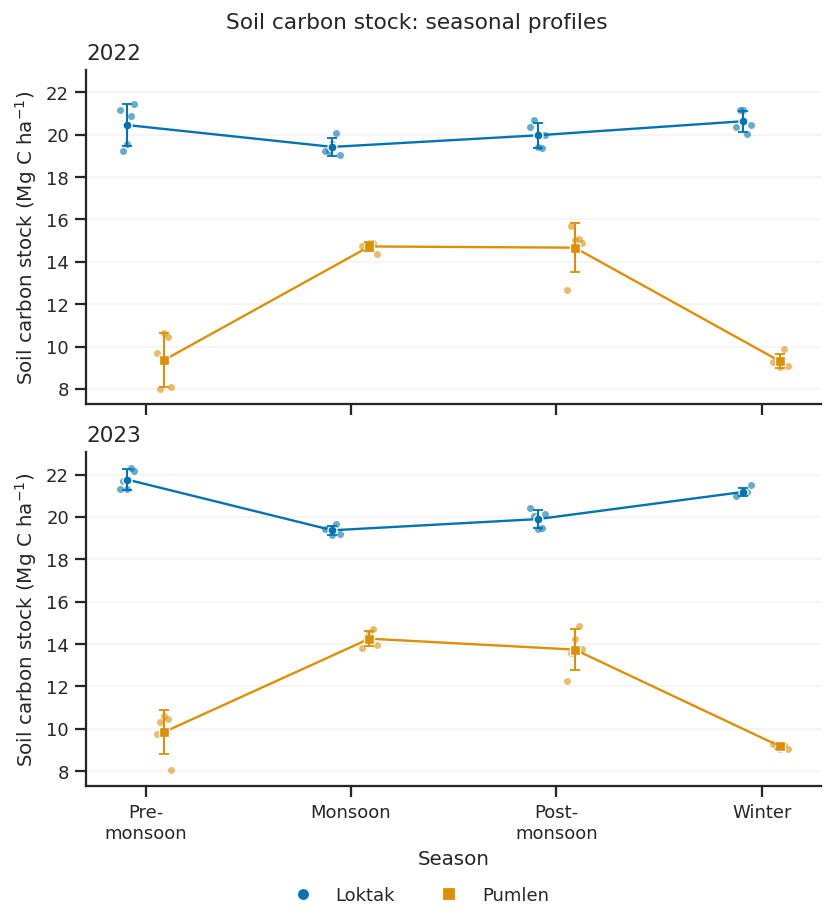

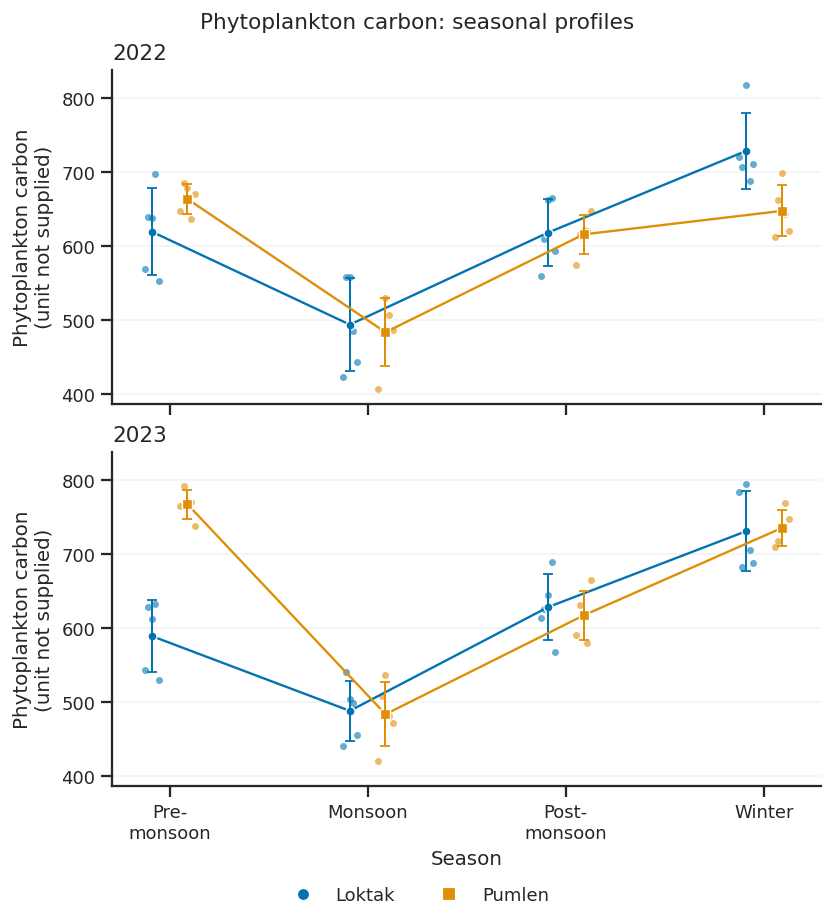

In [4]:
def seasonal_figure(variable):
    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, 7.0), sharex=True, sharey=True,
                             layout="constrained")
    for ax, year in zip(axes, [2022, 2023]):
        for lake in WETLANDS:
            offset = -0.09 if lake == "Loktak" else 0.09
            raw = data.query("Wetland == @lake and Year == @year").copy()
            raw["Position"] = raw.Season.map(dict(zip(SEASONS, range(4)))) + offset + (raw.Site-3)*0.018
            sns.scatterplot(data=raw, x="Position", y=variable, color=PALETTE[lake],
                            s=15, alpha=0.6, linewidth=0, legend=False, ax=ax)
            group = seasonal.query("Variable == @variable and Wetland == @lake and Year == @year").set_index("Season").loc[SEASONS]
            x = np.arange(4) + offset
            sns.lineplot(x=x, y=group.Mean.to_numpy(), color=PALETTE[lake],
                         marker="o" if lake == "Loktak" else "s", markersize=5,
                         linewidth=1.3, errorbar=None, ax=ax)
            ax.errorbar(x, group.Mean, yerr=group.SD, fmt="none", capsize=3,
                        color=PALETTE[lake], linewidth=1.1)
        ax.set_title(str(year), loc="left")
        set_numeric_axis(ax, "y", data[variable], variable)
        ax.set(xlabel="", xticks=range(4), xticklabels=SEASON_TICKS)
        ax.grid(axis="y", alpha=0.2)
    axes[-1].set_xlabel("Season")
    fig.legend(handles=lake_handles(shape_by_lake=True), loc="outside lower center", ncol=2, frameon=False)
    title = "Soil carbon stock" if variable == "Soil_stock" else "Phytoplankton carbon"
    fig.suptitle(title + ": seasonal profiles", fontsize=12)
    save_show(fig, f"seasonal_{variable}",
              f"{title} by lake, year and season. Small points are site values; lines show means and bars show sample SD across five sites. Equal site weighting; repeated sites across seasons. Source: Scatter Plot.xlsx. "
              + ("Unit: Mg C per hectare." if variable == "Soil_stock" else "Phytoplankton-carbon unit is not supplied."))

seasonal_figure("Soil_stock")
seasonal_figure("Phyto_carbon")

### What the seasonal plots show

Across the supplied site records, soil carbon stock is higher in Loktak: all its
values are **19.05–22.33 Mg C ha⁻¹**, compared with **8.01–15.69** in Pumlen.
Loktak varies relatively little through the seasons; Pumlen has higher seasonal
means in monsoon and post-monsoon than in pre-monsoon and winter, in both years.

Phytoplankton carbon has its lowest seasonal mean in the monsoon in both lakes and
years. Loktak's highest mean occurs in winter; Pumlen's occurs in pre-monsoon.
These are patterns in measured stocks/content, not estimates of productivity or
carbon uptake rates. The audit above identifies the discrepant reported monsoon mean.

### TBC: reported seasonal means only

The following values come from `Line_Graph!F8:I11`. The “±” values are retained in
the summary table but **not drawn as error bars**, because SD, SE and confidence
intervals have different meanings and the source does not identify which is supplied.
The summary's unit also needs confirmation. No site-level TBC relationship is fitted.

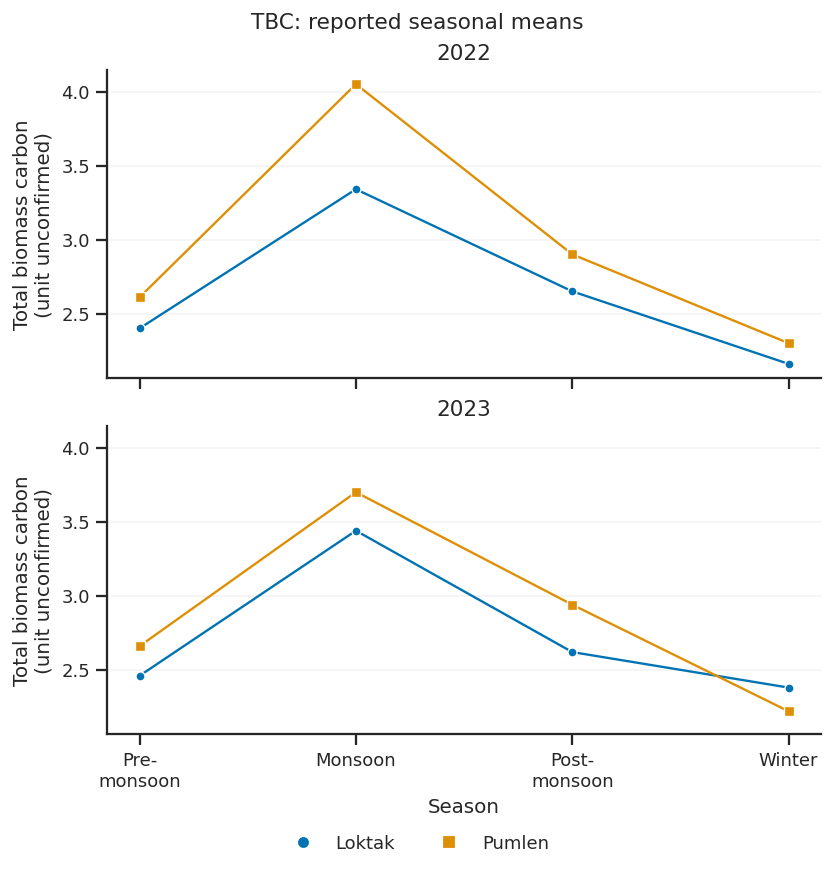

In [5]:
reported.to_csv(TABLE_DIR / "seasonal_summary_as_reported.csv", index=False)
fig, axes = plt.subplots(2, 1, figsize=(WIDTH, 6.6), sharex=True, sharey=True, layout="constrained")
for ax, year in zip(axes, [2022, 2023]):
    for lake in WETLANDS:
        group = reported.query("Variable == 'TBC' and Wetland == @lake and Year == @year").set_index("Season").loc[SEASONS]
        sns.lineplot(x=np.arange(4), y=group.Mean.to_numpy(), color=PALETTE[lake],
                     marker="o" if lake == "Loktak" else "s", markersize=5,
                     linewidth=1.3, errorbar=None, ax=ax)
    ax.set(title=str(year), xlabel="", ylabel=LABELS["TBC"], xticks=range(4), xticklabels=SEASON_TICKS)
    ax.grid(axis="y", alpha=0.2)
axes[-1].set_xlabel("Season")
fig.legend(handles=lake_handles(shape_by_lake=True), loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("TBC: reported seasonal means", fontsize=12)
save_show(fig, "seasonal_TBC_reported_only",
          "Reported TBC means from Scatter Plot.xlsx, Line_Graph. The monsoon mean is highest in both lakes and years. Units and the meaning of the supplied +/- values are unconfirmed, so no error bars are drawn. The TBC-labelled raw block duplicates TDS and is excluded.")

## 3. Environmental associations within each lake

One figure shows one predictor, with separate panels for the two lakes. The **x-axis
limits are shared**, while **y-axis limits differ between lakes** to reveal variation
that was compressed in the pooled plots. Compare the ticks, not the apparent angle
of a point cloud. The seasonal figures above provide the absolute between-lake comparison.

Each point is a paired observation, colour identifies lake and shape identifies season;
both years are included. Numeric coordinates are not jittered or transformed. Exact
coincidences can still overlap. No fitted lines, confidence bands or p-values are added.

SOC and bulk density can enter stock calculations. Their association with soil stock
can include mathematical coupling; the full calculation protocol is not supplied.

In [6]:
soil_predictors = ["Soil_Temp", "Soil_pH", "BD", "Moisture", "SOC", "N", "P", "K"]

def scatter_by_lake(response, predictor):
    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, 7.0), sharex=True, layout="constrained")
    for ax, lake in zip(axes, WETLANDS):
        subset = data.query("Wetland == @lake")
        sns.scatterplot(data=subset, x=predictor, y=response, style="Season",
                        style_order=SEASONS, markers=MARKERS, color=PALETTE[lake],
                        s=30, alpha=0.8, edgecolor="white", linewidth=0.3,
                        legend=False, ax=ax)
        set_numeric_axis(ax, "x", data[predictor], predictor)
        set_numeric_axis(ax, "y", subset[response], response)
        ax.set_title(lake + " (40 records)", loc="left")
        ax.grid(alpha=0.18)
        ax.margins(y=0.12)
    axes[0].set_xlabel("")
    fig.legend(handles=season_handles(), loc="outside lower center", ncol=2, frameon=False)
    response_name = "Soil carbon stock" if response == "Soil_stock" else "Phytoplankton carbon"
    fig.suptitle(response_name + " versus " + LABELS[predictor] + "\nShared x-range; lake-specific y-ranges", fontsize=11)
    save_show(fig, f"scatter_{response}_{predictor}",
              f"{response_name} versus {LABELS[predictor]}. Panels separate lakes; seasons use different symbols. Both years are included (40 records per lake). X limits are shared, but y limits are lake-specific; apparent slopes should not be compared across panels. Numeric values are unaltered. Environmental units are not supplied.")

### Physical soil variables

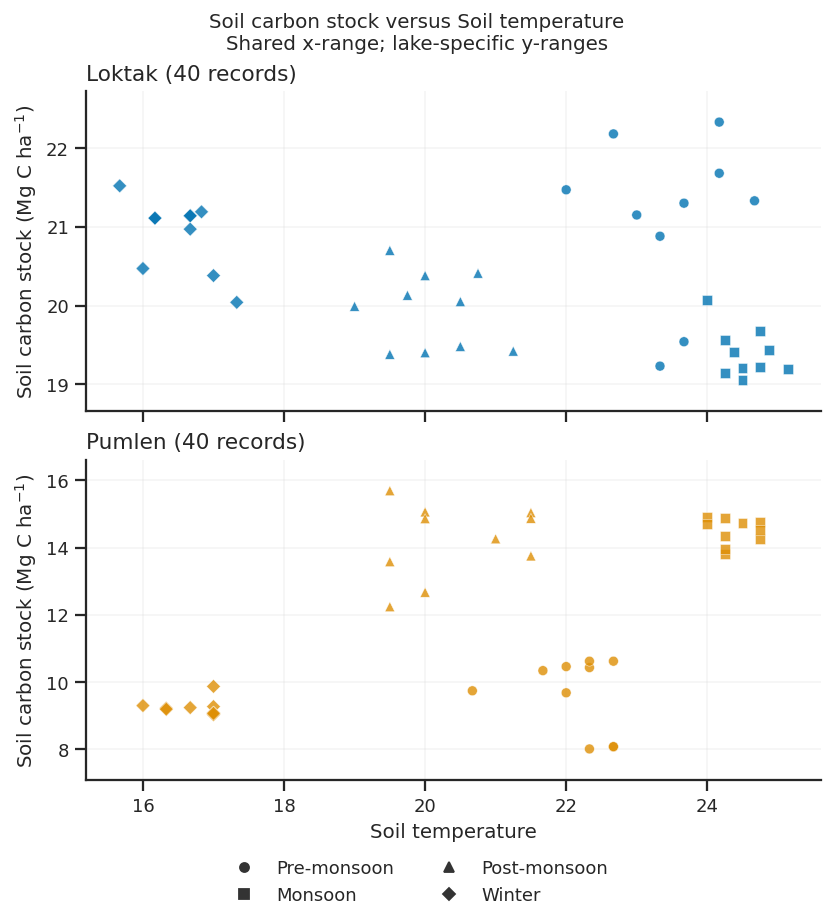

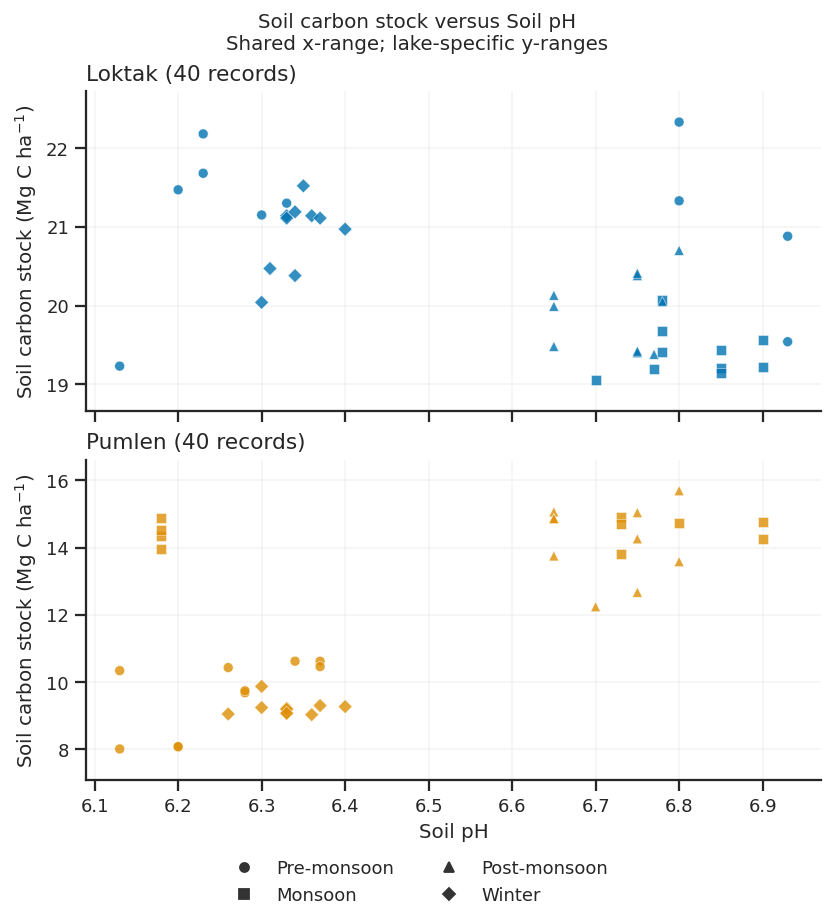

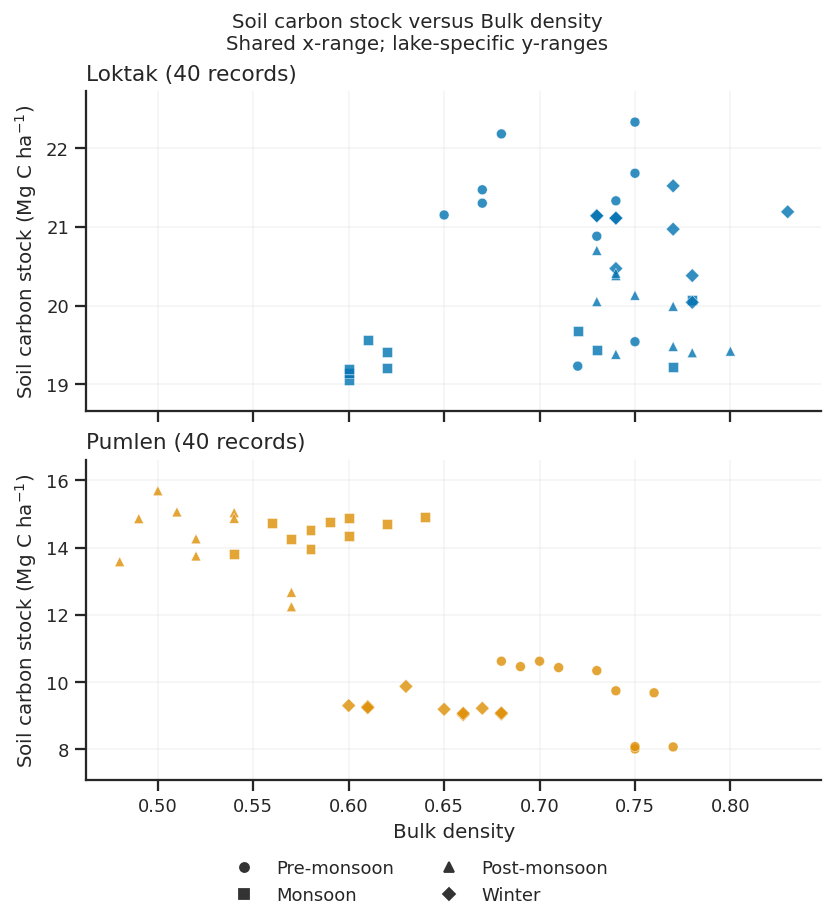

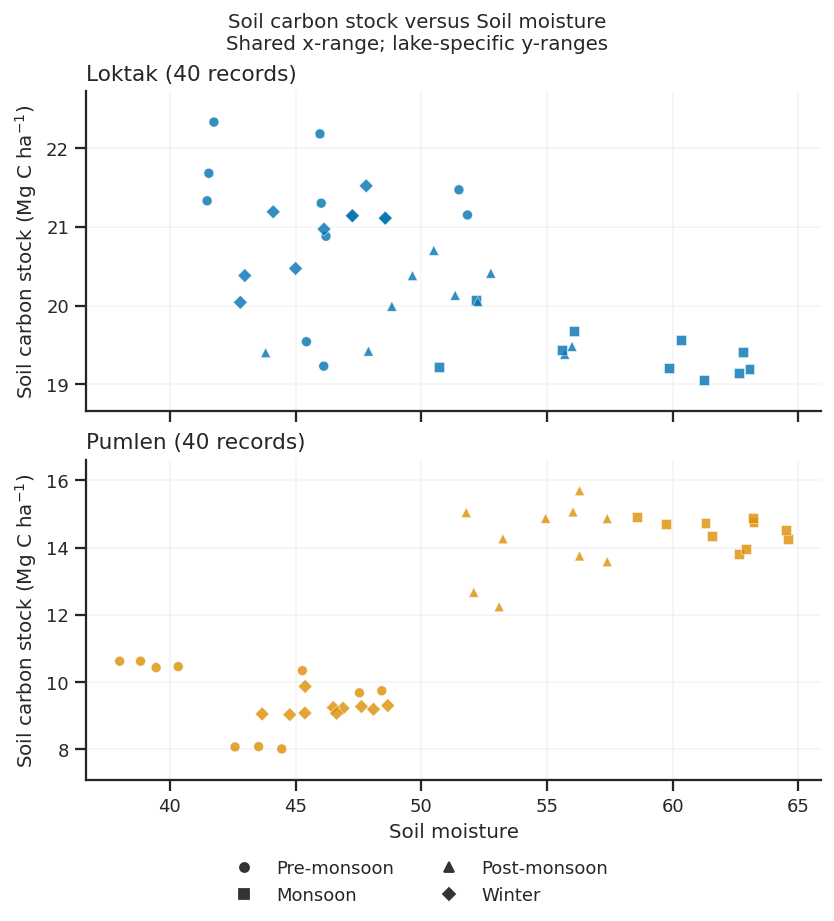

In [7]:
for predictor in soil_predictors[:4]:
    scatter_by_lake("Soil_stock", predictor)

### SOC and soil nutrients

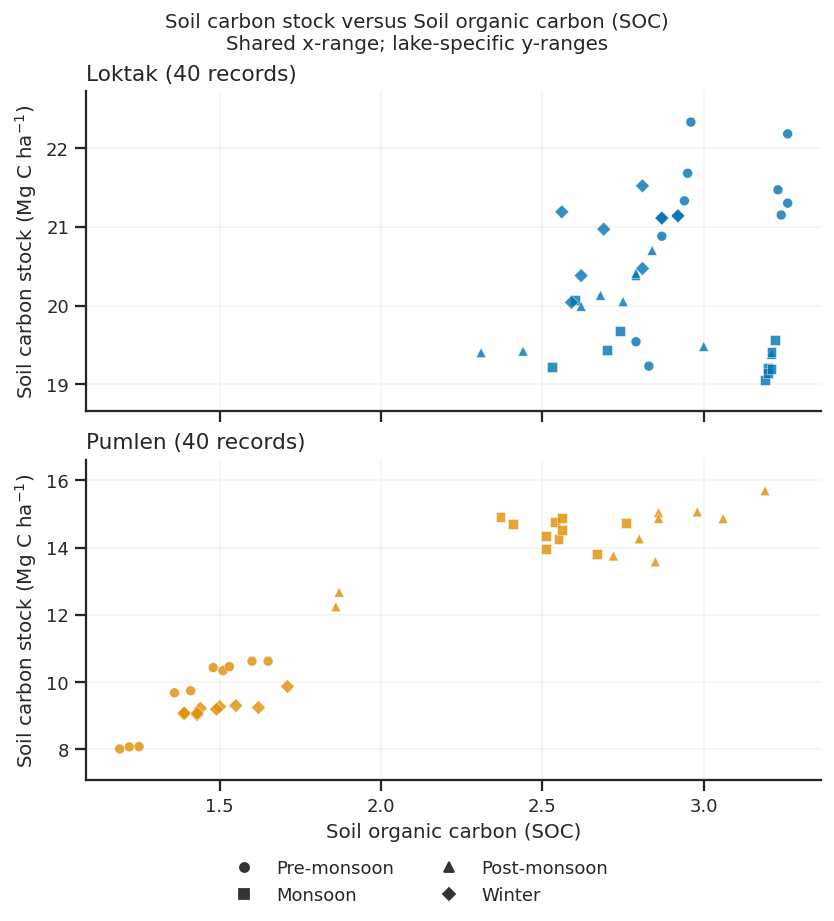

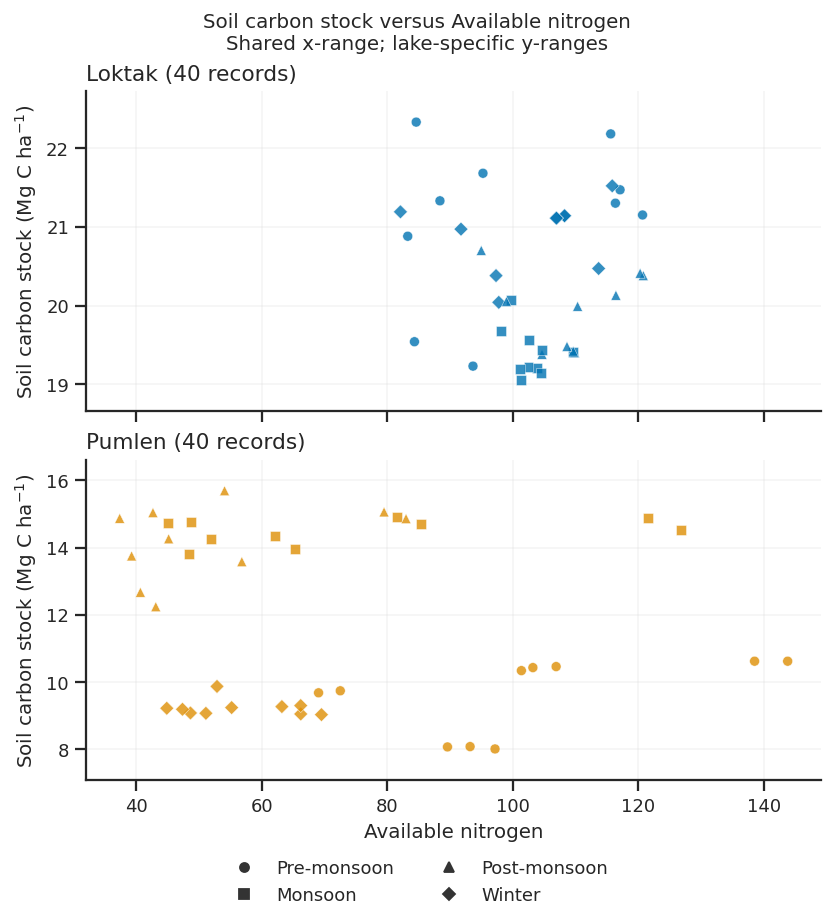

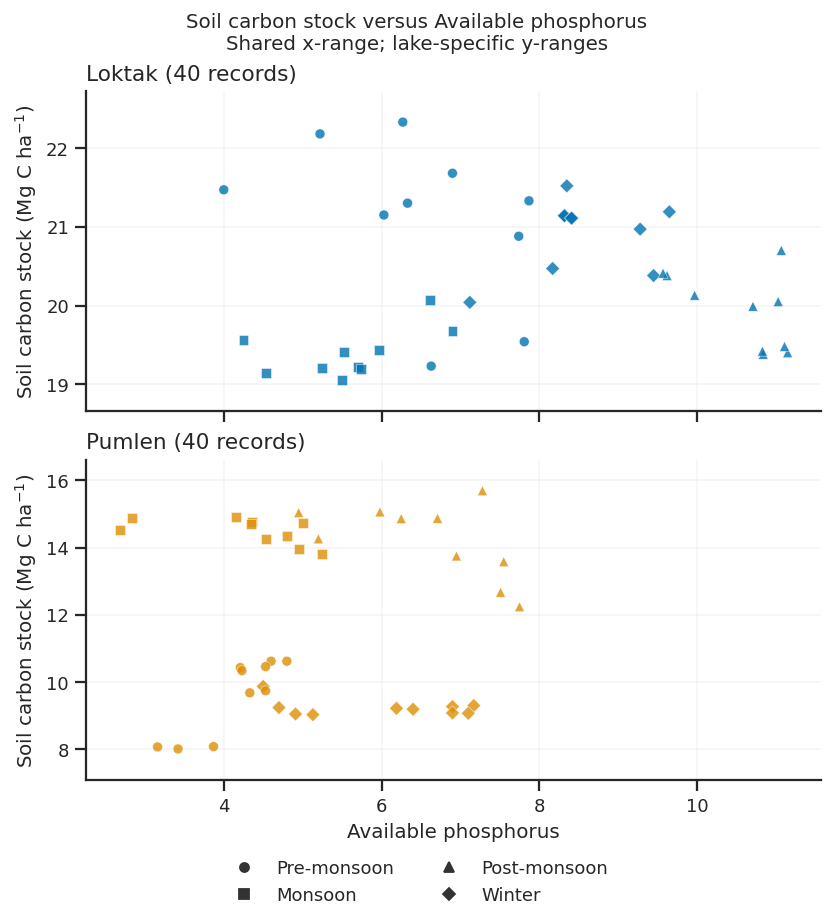

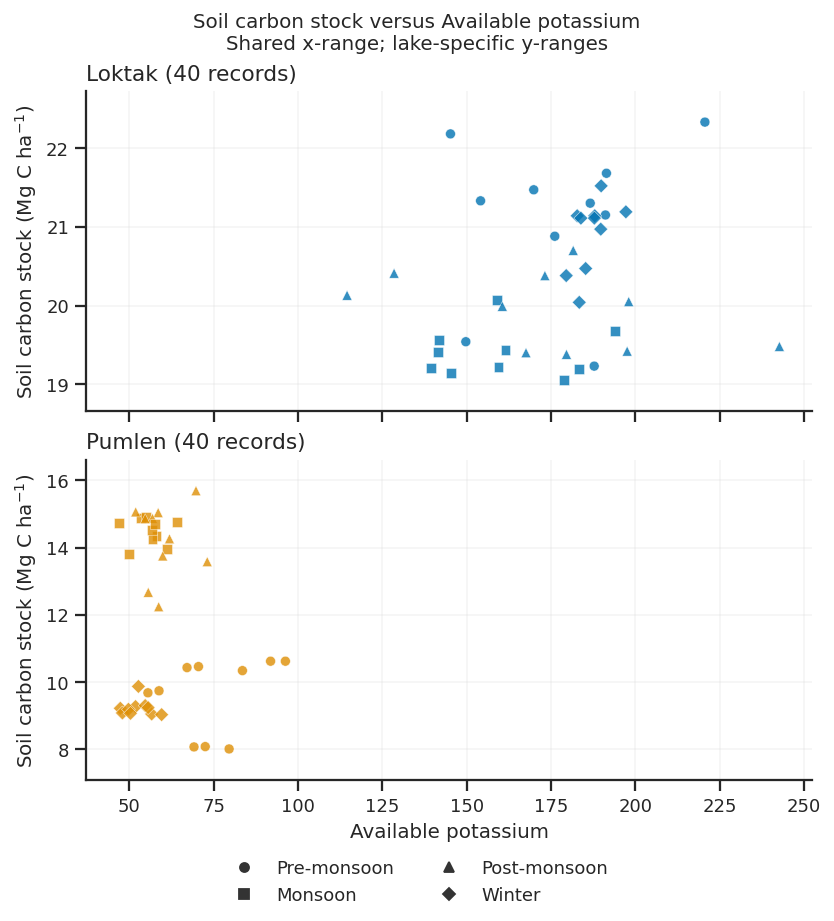

In [8]:
for predictor in soil_predictors[4:]:
    scatter_by_lake("Soil_stock", predictor)

### Water variables and phytoplankton carbon

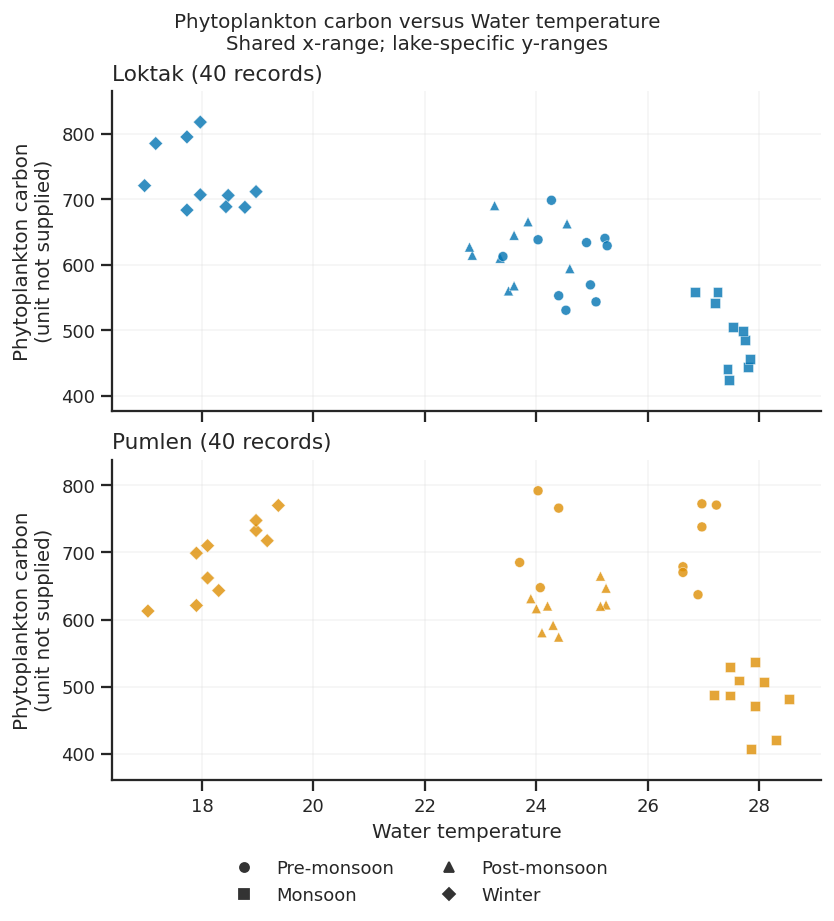

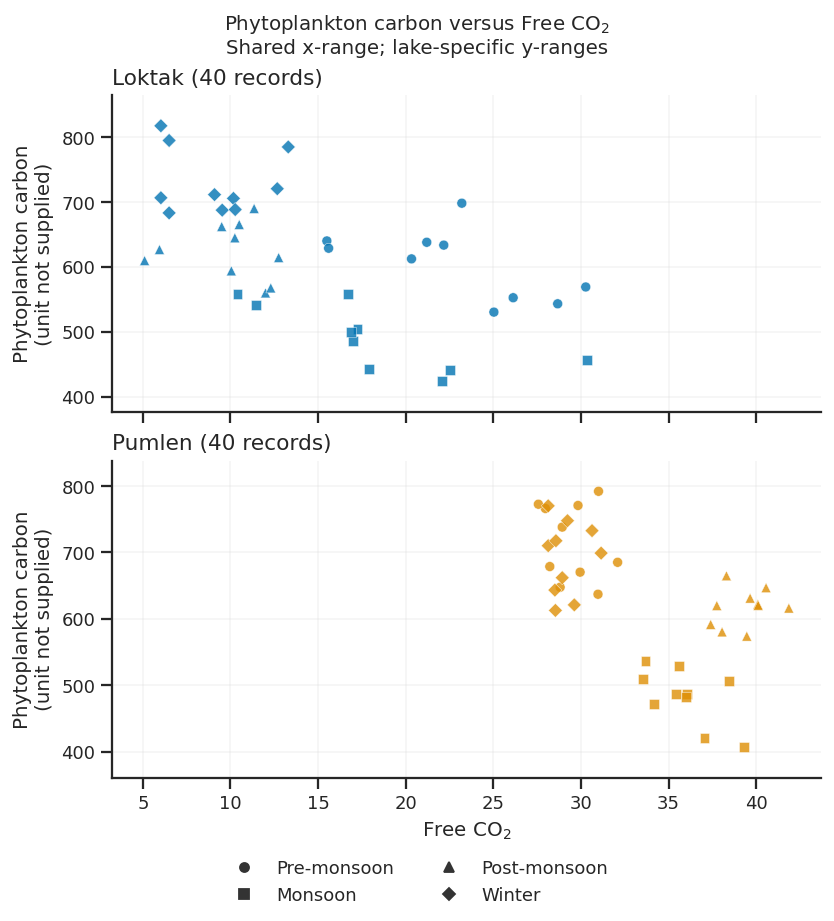

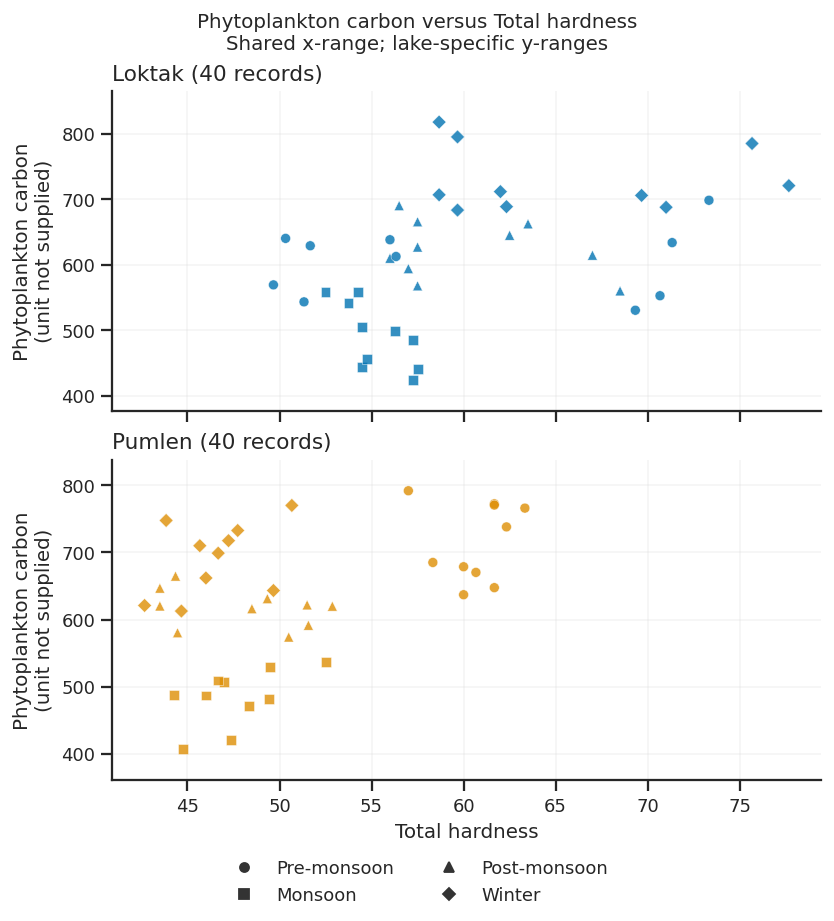

In [9]:
for predictor in ["Water_Temp", "CO2", "Hardness"]:
    scatter_by_lake("Phyto_carbon", predictor)

## 4. Compare pooled and within-lake correlations

Pearson's r describes a linear association in the original values. The table uses
the same paired measurements as the plots. Here n counts records, not independent
sites. Within-lake correlations still mix seasons, years and repeated sites.

In [10]:
associations = []
for response, predictors in [("Soil_stock", soil_predictors),
                             ("Phyto_carbon", ["Water_Temp", "CO2", "Hardness"])]:
    for predictor in predictors:
        row = {"Response": response, "Predictor": predictor}
        for group, subset in [("Pooled (n=80)", data)] + [(lake+" (n=40)", data.query("Wetland == @lake")) for lake in WETLANDS]:
            row[group] = subset[[predictor, response]].corr().iloc[0, 1]
        associations.append(row)
associations = pd.DataFrame(associations)
display(associations.round(3))
associations.to_csv(TABLE_DIR / "pooled_and_within_lake_correlations.csv", index=False)

,Response,Predictor,Pooled (n=80),Loktak (n=40),Pumlen (n=40)
0,Soil_stock,Soil_Temp,0.146,-0.326,0.548
1,Soil_stock,Soil_pH,0.360,-0.547,0.674
2,Soil_stock,BD,0.345,0.240,-0.790
3,Soil_stock,Moisture,0.122,-0.631,0.834
4,Soil_stock,SOC,0.865,0.121,0.958
5,Soil_stock,N,0.510,0.005,-0.157
6,Soil_stock,P,0.539,-0.005,0.061
7,Soil_stock,K,0.863,0.239,-0.170
8,Phyto_carbon,Water_Temp,-0.661,-0.863,-0.500
9,Phyto_carbon,CO2,-0.245,-0.581,-0.597


## Conclusions for the supplied measurements

- **The between-lake contrast matters.** Soil stock and available K have pooled
  r = **0.863**, but within-lake r is **0.239** in Loktak and **−0.170** in Pumlen.
  The large pooled coefficient cannot be read as a common within-lake relationship.
- **Some associations differ in direction.** Soil stock versus moisture has pooled
  r = **0.122**, compared with **−0.631** in Loktak and **0.834** in Pumlen.
  A weak pooled result therefore does not imply little structure within each lake.
- **Phytoplankton carbon and water temperature are negatively associated** in both
  lakes (r = **−0.863**, **−0.500**; pooled **−0.661**). Seasonality is visible in
  these plots, so this is not an isolated temperature effect.
- **The TBC summary peaks in monsoon**, but authentic site-level TBC data, its unit
  and the definition of its reported spread are needed before further interpretation.

These conclusions concern the sampled site records. They do not establish causation,
whole-lake totals, effects of protection/disturbance or sequestration rates. Use
notebook 02 for the reported correlation matrices and notebook 03 for environmental PCA.